
#  INT303 Big Data Analytics


## Lab 3 Pandas

**XJTLU**<br>
**S1 2025**<br>
**Instructors:** Pengfei Fan <br>
**Lab Instructor:** Pengfei Fan <br>


---

## The basic Exploratory Data Analysis (EDA) workflow

Below is a basic checklist for the early stages of exploratory data analysis in Python. 

While not universally applicable, the **rubric** covers patterns which recur in several data analysis contexts, so useful to keep it in mind when encountering a new dataset.

In [50]:
# The %... is an iPython thing, and is not part of the Python language.
# In this case we're just telling the plotting library to draw things on
# the notebook, instead of on a separate window.

# See all the "as ..." contructs? They're just aliasing the package names.
# That way we can call methods like plt.plot() instead of matplotlib.pyplot.plot().
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.notebook_repr_html', True)
#import seaborn as sns
#sns.set_style("whitegrid")
#sns.set_context("poster")

### Building a dataframe

This is a file of people who have contributed money to candidates:

In [51]:
dfcwci=pd.read_csv("contributors_with_candidate_id.txt", sep="|")
dfcwci.head(2)

,id,last_name,first_name,middle_name,street_1,street_2,city,state,zip,amount,date,candidate_id
0,NaN,Agee,Steven,NaN,549 Laurel Branch Road,NaN,Floyd,VA,24091,500.0,2007-06-30,16
1,NaN,Ahrens,Don,NaN,4034 Rennellwood Way,NaN,Pleasanton,CA,94566,250.0,2007-05-16,16


In [52]:
del dfcwci['id']
dfcwci.head(2)

,last_name,first_name,middle_name,street_1,street_2,city,state,zip,amount,date,candidate_id
0,Agee,Steven,NaN,549 Laurel Branch Road,NaN,Floyd,VA,24091,500.0,2007-06-30,16
1,Ahrens,Don,NaN,4034 Rennellwood Way,NaN,Pleasanton,CA,94566,250.0,2007-05-16,16


### QUERY

In [53]:
dfcwci.amount < 400

0      False
1       True
2       True
3       True
4       True
       ...  
170     True
171    False
172     True
173    False
174    False
Name: amount, Length: 175, dtype: bool

This gives us Trues and Falses. Such a series is called a **mask**.  A mask  is the basis of filtering. We can do:

In [54]:
dfcwci[dfcwci.amount < 400].head(2)

,last_name,first_name,middle_name,street_1,street_2,city,state,zip,amount,date,candidate_id
1,Ahrens,Don,NaN,4034 Rennellwood Way,NaN,Pleasanton,CA,94566,250.0,2007-05-16,16
2,Ahrens,Don,NaN,4034 Rennellwood Way,NaN,Pleasanton,CA,94566,50.0,2007-06-18,16


Notice that the dataframe has been filtered down to only include those contributions with amount < 400. The rows with `False` in the mask have been eliminated, and those with `True` in the mask have been kept.

In [55]:
np.sum(dfcwci.amount < 400), np.mean(dfcwci.amount < 400)

(132, 0.7542857142857143)

Why did that work? The booleans are coerced to integers as below:

In [56]:
1*True, 5*False

(1, 0)

Or directly, in Pandas, which works since the comparison is a pandas Series.

In [57]:
(dfcwci.amount < 400).mean()

0.7542857142857143

You can combine queries. Note that we use Python's `&` operator instead of `and`. This is because we are "Boolean AND"ing masks to get a series of True's And Falses.

In [58]:
dfcwci[(dfcwci.state=='VA') & (dfcwci.amount < 400)].head(2)

,last_name,first_name,middle_name,street_1,street_2,city,state,zip,amount,date,candidate_id
27,Buckheit,Bruce,NaN,8904 KAREN DR,NaN,FAIRFAX,VA,220312731,100.0,2007-09-19,20
77,Ranganath,Anoop,NaN,2507 Willard Drive,NaN,Charlottesville,VA,22903,-100.0,2008-04-21,32


In [59]:
dfcwci[(dfcwci['last_name']=='BYERS')]

,last_name,first_name,middle_name,street_1,street_2,city,state,zip,amount,date,candidate_id
52,BYERS,BOB,A.,13170 TELFAIR AVENUE,NaN,SYLMAR,CA,913423573,-2300.0,2008-03-07,22
53,BYERS,AUDREY,NaN,2658 LADBROOK WAY,NaN,THOUSAND OAKS,CA,913615073,-200.0,2008-03-07,22


For cleaning, we might want to use this querying ability

In [60]:
dfcwci[dfcwci.state.isnull()]

,last_name,first_name,middle_name,street_1,street_2,city,state,zip,amount,date,candidate_id
125,BOURNE,TRAVIS,NaN,LAGE KAART 77,NaN,BRASSCHATT,NaN,2930,-500.0,2008-11-20,35


And you can chain queries thus.


In [61]:
dfcwci.query("10 <= amount <= 50").head(2)

,last_name,first_name,middle_name,street_1,street_2,city,state,zip,amount,date,candidate_id
2,Ahrens,Don,NaN,4034 Rennellwood Way,NaN,Pleasanton,CA,94566,50.0,2007-06-18,16
18,Ardle,William,NaN,412 Dakota Avenue,NaN,Springfield,OH,45504,50.0,2007-06-28,16


For categoricals you can use `isin`. You can use Boolean not on the mask to implement not in.

In [62]:
dfcwci[dfcwci.state.isin(['VA','WA'])].head(2)

,last_name,first_name,middle_name,street_1,street_2,city,state,zip,amount,date,candidate_id
0,Agee,Steven,NaN,549 Laurel Branch Road,NaN,Floyd,VA,24091,500.0,2007-06-30,16
27,Buckheit,Bruce,NaN,8904 KAREN DR,NaN,FAIRFAX,VA,220312731,100.0,2007-09-19,20


### Drop Null


Or the opposite, which is probably more useful in making the selection:

In [63]:
dfcwci[dfcwci.state.notnull()].head(2)

,last_name,first_name,middle_name,street_1,street_2,city,state,zip,amount,date,candidate_id
0,Agee,Steven,NaN,549 Laurel Branch Road,NaN,Floyd,VA,24091,500.0,2007-06-30,16
1,Ahrens,Don,NaN,4034 Rennellwood Way,NaN,Pleasanton,CA,94566,250.0,2007-05-16,16


### SORT

In [64]:
dfcwci.sort_values(by="amount").head(2)

,last_name,first_name,middle_name,street_1,street_2,city,state,zip,amount,date,candidate_id
90,Kazor,Christopher,M,707 Spindletree ave,NaN,Naperville,IL,60565,-2592.0,2008-04-21,32
72,BRUNO,JOHN,NaN,10136 WINDERMERE CHASE BLVD.,NaN,GOTHA,FL,347344707,-2300.0,2008-03-06,22


In [65]:
dfcwci.sort_values(by="amount", ascending=False).head(3)

,last_name,first_name,middle_name,street_1,street_2,city,state,zip,amount,date,candidate_id
30,Buckel,Linda,NaN,PO Box 683130,NaN,Park City,UT,840683130,4600.0,2007-08-14,20
159,ABATE,MARIA,ELENA,1291 NIGHTINGALE AVENUE,NaN,MIAMI SPRINGS,FL,331663832,2600.0,2008-01-25,37
15,Anthony,John,NaN,211 Long Island Drive,NaN,Hot Springs,AR,71913,2300.0,2007-06-12,16


### SELECT-COLUMNS

In [66]:
dfcwci[['first_name', 'amount']].head(2)

,first_name,amount
0,Steven,500.0
1,Don,250.0


### SELECT-DISTINCT

Here, we might wish to focus on contributors rather than contributions and see how many distinct contributors we have. Of-course we might be wrong, some people have identical names. 

In [67]:
dfcwci[['last_name','first_name']].count()

last_name     175
first_name    175
dtype: int64

In [68]:
dfcwci[['last_name','first_name']].drop_duplicates().count()

last_name     126
first_name    126
dtype: int64

In [69]:
dfcwci[['last_name','first_name']].drop_duplicates().head(3)

,last_name,first_name
0,Agee,Steven
1,Ahrens,Don
4,Akin,Charles


### SLICING
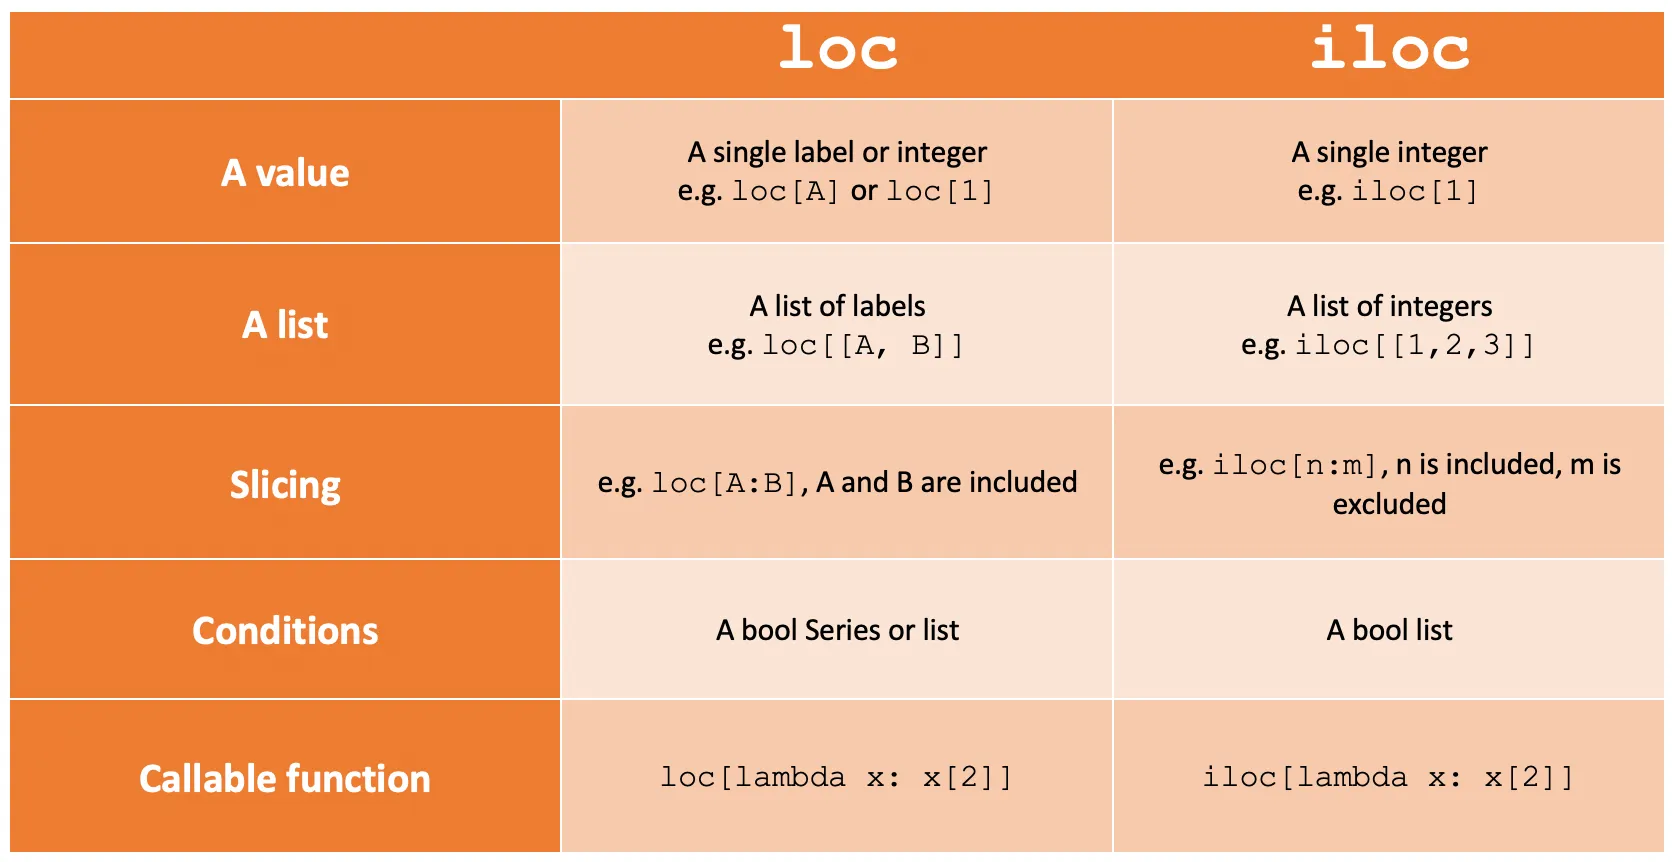

In [70]:
dfcwci[0:3] # also see loc and iloc from the lab

,last_name,first_name,middle_name,street_1,street_2,city,state,zip,amount,date,candidate_id
0,Agee,Steven,NaN,549 Laurel Branch Road,NaN,Floyd,VA,24091,500.0,2007-06-30,16
1,Ahrens,Don,NaN,4034 Rennellwood Way,NaN,Pleasanton,CA,94566,250.0,2007-05-16,16
2,Ahrens,Don,NaN,4034 Rennellwood Way,NaN,Pleasanton,CA,94566,50.0,2007-06-18,16


In [71]:
dfcwci.iloc[0:4,2:5]

,middle_name,street_1,street_2
0,NaN,549 Laurel Branch Road,NaN
1,NaN,4034 Rennellwood Way,NaN
2,NaN,4034 Rennellwood Way,NaN
3,NaN,4034 Rennellwood Way,NaN


In [72]:
dfcwci.loc[0:4,['middle_name','street_1']]

,middle_name,street_1
0,NaN,549 Laurel Branch Road
1,NaN,4034 Rennellwood Way
2,NaN,4034 Rennellwood Way
3,NaN,4034 Rennellwood Way
4,NaN,10187 Sugar Creek Road


### ASSIGN

Assignment to a new column is easy.

In [73]:
dfcwci['name']=dfcwci['last_name']+", "+dfcwci['first_name']
dfcwci.head(3)

,last_name,first_name,middle_name,street_1,street_2,city,state,zip,amount,date,candidate_id,name
0,Agee,Steven,NaN,549 Laurel Branch Road,NaN,Floyd,VA,24091,500.0,2007-06-30,16,"Agee, Steven"
1,Ahrens,Don,NaN,4034 Rennellwood Way,NaN,Pleasanton,CA,94566,250.0,2007-05-16,16,"Ahrens, Don"
2,Ahrens,Don,NaN,4034 Rennellwood Way,NaN,Pleasanton,CA,94566,50.0,2007-06-18,16,"Ahrens, Don"


In [74]:
dfcwci.assign(ucname=dfcwci.last_name+":"+dfcwci.first_name).head(2)

,last_name,first_name,middle_name,street_1,street_2,city,state,zip,amount,date,candidate_id,name,ucname
0,Agee,Steven,NaN,549 Laurel Branch Road,NaN,Floyd,VA,24091,500.0,2007-06-30,16,"Agee, Steven",Agee:Steven
1,Ahrens,Don,NaN,4034 Rennellwood Way,NaN,Pleasanton,CA,94566,250.0,2007-05-16,16,"Ahrens, Don",Ahrens:Don


### Will the above command actually change `dfcwci`? No, it produces a fresh dataframe.


In [75]:
dfcwci.head(2)

,last_name,first_name,middle_name,street_1,street_2,city,state,zip,amount,date,candidate_id,name
0,Agee,Steven,NaN,549 Laurel Branch Road,NaN,Floyd,VA,24091,500.0,2007-06-30,16,"Agee, Steven"
1,Ahrens,Don,NaN,4034 Rennellwood Way,NaN,Pleasanton,CA,94566,250.0,2007-05-16,16,"Ahrens, Don"


### AGGREGATE

In [76]:
dfcwci.describe()

,zip,amount,candidate_id
count,1.750000e+02,175.000000,175.000000
mean,3.780014e+08,3.418114,28.000000
std,3.628278e+08,1028.418999,7.823484
min,2.474000e+03,-2592.000000,16.000000
25%,9.336700e+04,-175.000000,20.000000
50%,3.233313e+08,100.000000,32.000000
75%,7.816946e+08,300.000000,35.000000
max,9.951532e+08,4600.000000,37.000000


In [77]:
dfcwci.amount.max()

4600.0

In [78]:
dfcwci[dfcwci.amount==dfcwci.amount.max()]

,last_name,first_name,middle_name,street_1,street_2,city,state,zip,amount,date,candidate_id,name
30,Buckel,Linda,NaN,PO Box 683130,NaN,Park City,UT,840683130,4600.0,2007-08-14,20,"Buckel, Linda"


In [79]:
dfcwci[dfcwci.amount > dfcwci.amount.max() - 2300]

,last_name,first_name,middle_name,street_1,street_2,city,state,zip,amount,date,candidate_id,name
30,Buckel,Linda,NaN,PO Box 683130,NaN,Park City,UT,840683130,4600.0,2007-08-14,20,"Buckel, Linda"
159,ABATE,MARIA,ELENA,1291 NIGHTINGALE AVENUE,NaN,MIAMI SPRINGS,FL,331663832,2600.0,2008-01-25,37,"ABATE, MARIA"


## Grouping using Pandas and split-apply-combine

In [40]:
grouped_by_state = dfcwci.groupby("state")

How do we get access to these?

### GROUP-AGG

The fourth part of the EDA rubric is to look at properties of the sub-dataframes you get when you make groups. (We'll talk about the graphical aspects of this later). For instance, you might group contributions by state:

In [41]:
dfcwci.groupby("state").describe()[:3]

zip                                                                                            amount                                                                candidate_id                                         
      count          mean         std          min          25%          50%          75%          max  count         mean         std    min    25%     50%     75%     max        count  mean  std   min   25%   50%   75%   max
state                                                                                                                                                                                                                             
AK      3.0  9.951532e+08    0.000000  995153207.0  995153207.0  995153207.0  995153207.0  995153207.0    3.0   403.333333  100.166528  300.0  355.0   410.0   455.0   500.0          3.0  37.0  0.0  37.0  37.0  37.0  37.0  37.0
AR     12.0  7.206583e+04  425.025097      71603.0      71655.0      72033.5      72227.0      72903.0   12.0  1183.333333  775.574079  100.0  875.0  1000.0  1700.0  2300.0         12.0  16.0  0.0  16.0  16.0  16.0  16.0  16.0
AZ      1.0  8.600111e+08         NaN  860011121.0  860011121.0  860011121.0  860011121.0  860011121.0    1.0   120.000000         NaN  120.0  120.0   120.0   120.0   120.0          1.0  37.0  NaN  37.0  37.0  37.0  37.0  37.0

In [42]:
dfcwci.groupby("state").sum()[:3]

,last_name,first_name,middle_name,street_1,street_2,city,zip,amount,date,candidate_id,name
state,,,,,,,,,,,
AK,AARONSAARONSAARONS,CHARLESCHARLESCHARLES,0,1730 SHORE DRIVE1730 SHORE DRIVE1730 SHORE DRIVE,0,ANCHORAGEANCHORAGEANCHORAGE,2985459621,1210.0,2008-01-302008-01-152008-01-09,111,"AARONS, CHARLESAARONS, CHARLESAARONS, CHARLES"
AR,AkinAkinAkinAllisonAllisonAllisonAltesAnthonyA...,CharlesMikeRebeccaJohn W.RebeccaRebeccaR.D.Joh...,0,10187 Sugar Creek Road181 Baywood Lane181 Bayw...,0,BentonvilleMonticelloMonticelloConwayLittle Ro...,864790,14200.0,2007-06-162007-05-182007-05-182007-05-182007-0...,192,"Akin, CharlesAkin, MikeAkin, RebeccaAllison, J..."
AZ,ABESHAUS,MERRILL,M.,1801 N. HEREFORD DRIVE,0,FLAGSTAFF,860011121,120.0,2008-01-16,37,"ABESHAUS, MERRILL"


In [43]:
mydf = dfcwci.groupby("state")['amount'].sum()
mydf.sort_values()[:3]

state
NY   -6474.5
CO   -5823.0
IL   -5586.8
Name: amount, dtype: float64

In [44]:
dfcwci.groupby("state")['amount'].apply(lambda x: np.std(x))[:3]

state
AK     81.785628
AR    742.555647
AZ      0.000000
Name: amount, dtype: float64

The dictionary-like structure is more obvious in this method of iteration, but it does not do the combining part...

In [45]:
for k, v in dfcwci.groupby('state'):
    print("State", k, "mean amount", v.amount.mean(), "std", v.amount.std())

State AK mean amount 403.3333333333333 std 100.16652800877813
State AR mean amount 1183.3333333333333 std 775.574078676661
State AZ mean amount 120.0 std nan
State CA mean amount -217.9882608695652 std 942.1024379191479
State CO mean amount -1455.75 std 1025.16612474922
State CT mean amount 2300.0 std nan
State DC mean amount -309.98199999999997 std 529.6441745360747
State FL mean amount -135.0 std 1177.3838620520878
State IA mean amount 250.0 std nan
State ID mean amount -261.0 std nan
State IL mean amount -931.1333333333333 std 1230.6579811900083
State KS mean amount -330.0 std nan
State KY mean amount -200.0 std nan
State LA mean amount 650.0 std 212.13203435596427
State MA mean amount -13.833333333333334 std 248.19783775582468
State MD mean amount 150.0 std 141.4213562373095
State ME mean amount 630.0 std 1113.5229379466475
State MI mean amount -253.0 std 1156.630883212099
State MN mean amount 107.33333333333333 std 139.14500829470433
State MO mean amount 100.0 std nan
State NC mea

## Relationships: JOINs are Cartesian Products.

Finally, there are many occasions you will want to combine dataframes. We might want to see who contributed to Obama:

### INNER JOIN

This is the one you will want 90% of the time. It will only match keys that are present in both dataframes.

![inner join](http://pandas.pydata.org/pandas-docs/stable/_images/merging_merge_on_key_inner.png)

(from http://pandas.pydata.org/pandas-docs/stable/merging.html)

In [46]:
cols_wanted=['last_name_x', 'first_name_x', 'candidate_id', 'id', 'last_name_y']
dfcwci.merge(dfcand, left_on="candidate_id", right_on="id")[cols_wanted].head(2)

,last_name_x,first_name_x,candidate_id,id,last_name_y
0,Agee,Steven,16,16,Huckabee
1,Ahrens,Don,16,16,Huckabee


### Outer JOIN

#### left outer (contributors on candidates)

![left outer](http://pandas.pydata.org/pandas-docs/stable/_images/merging_merge_on_key_left.png)

In [47]:
dfcwci.merge(dfcand, left_on="candidate_id", right_on="id", how="left")[cols_wanted].head(2)

,last_name_x,first_name_x,candidate_id,id,last_name_y
0,Agee,Steven,16,16,Huckabee
1,Ahrens,Don,16,16,Huckabee


#### right outer (contributors on candidates) = left outer (candidates on contributors)

![right outer](http://pandas.pydata.org/pandas-docs/stable/_images/merging_merge_on_key_right.png)

In [48]:
dfcwci.merge(dfcand, left_on="candidate_id", right_on="id", how="right")[cols_wanted].head(2)

,last_name_x,first_name_x,candidate_id,id,last_name_y
0,NaN,NaN,NaN,33,Biden
1,NaN,NaN,NaN,36,Brownback


#### full outer

![outer](http://pandas.pydata.org/pandas-docs/stable/_images/merging_merge_on_key_outer.png)

In [49]:
dfcwci.merge(dfcand, left_on="candidate_id", right_on="id", how="outer")[cols_wanted].head(2)

,last_name_x,first_name_x,candidate_id,id,last_name_y
0,Agee,Steven,16.0,16,Huckabee
1,Ahrens,Don,16.0,16,Huckabee


When to use which?

See this:

http://blog.codinghorror.com/a-visual-explanation-of-sql-joins/

## Useful Links

- http://sebastianraschka.com/Articles/sqlite3_database.html and  http://sebastianraschka.com/Articles/2014_sqlite_in_python_tutorial.html#unique_indexes
- https://github.com/tthibo/SQL-Tutorial
- http://chrisalbon.com
